# Tutorial 6i: Thin Film Tolerance Analysis

This tutorial demonstrates **sensitivity analysis** and **Monte Carlo simulation** for thin film stacks, applied to a realistic 7-layer broadband AR coating on N-BK7 glass (designed via needle synthesis in Tutorial 6h).

Manufacturing variations in layer thickness shift spectral performance. We answer:
- Which layers are most critical? (sensitivity analysis)
- What is the expected yield under realistic tolerances? (Monte Carlo)
- What does the worst-case reflectance spectrum look like? (spectral tolerance band)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from optiland.materials import Material, IdealMaterial
from optiland.thin_film import ThinFilmStack
from optiland.thin_film.optimization.operand.thin_film import ThinFilmOperand
from optiland.thin_film.tolerancing import (
    ThinFilmTolerancing,
    ThinFilmSensitivityAnalysis,
    ThinFilmMonteCarlo,
)
from optiland.tolerancing.perturbation import RangeSampler, DistributionSampler

## 1. Nominal design: 7-layer broadband AR on N-BK7

This is the optimized design from Tutorial 6h (needle synthesis). It uses alternating MgF2/Al2O3 layers to achieve R < 1% across 420–680 nm.

In [2]:
air = IdealMaterial(n=1.0)
nbk7 = Material("N-BK7")
mgf2 = Material("MgF2", reference="Dodge-o")
al2o3 = Material("Al2O3", reference="Malitson")

# 7-layer design from needle synthesis (Tutorial 6h)
stack = ThinFilmStack(incident_material=air, substrate_material=nbk7)
stack.add_layer_nm(mgf2, 94.6, name="MgF2")
stack.add_layer_nm(al2o3, 319.7, name="Al2O3")
stack.add_layer_nm(mgf2, 17.7, name="MgF2")
stack.add_layer_nm(al2o3, 196.1, name="Al2O3")
stack.add_layer_nm(mgf2, 26.3, name="MgF2")
stack.add_layer_nm(al2o3, 170.9, name="Al2O3")
stack.add_layer_nm(mgf2, 190.4, name="MgF2")
print(stack)

ThinFilmStack Summary
---------------------
Incident:  IdealMaterial
Substrate: N-BK7
Layers:
  1. MgF2 (94.6 nm)
  2. Al2O3 (319.7 nm)
  3. MgF2 (17.7 nm)
  4. Al2O3 (196.1 nm)
  5. MgF2 (26.3 nm)
  6. Al2O3 (170.9 nm)
  7. MgF2 (190.4 nm)
---------------------
Total Thickness: 1015.7 nm


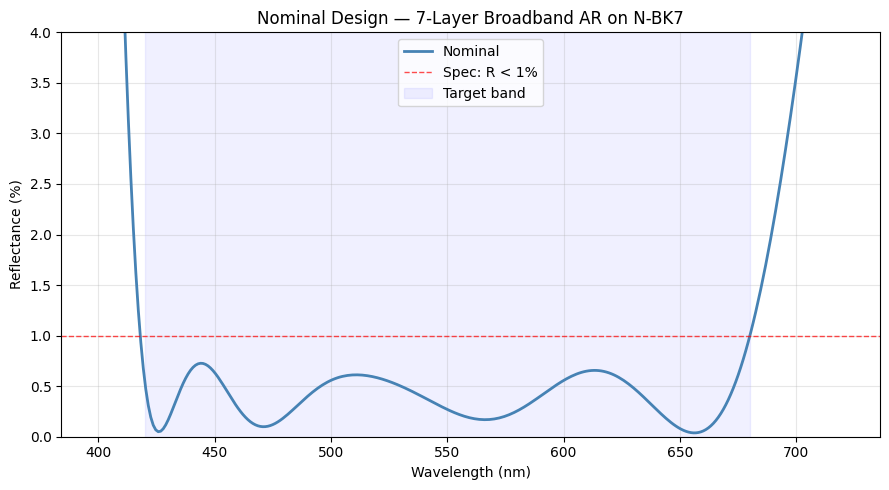

In [3]:
wl_plot = np.linspace(400, 720, 300)
R_nominal = np.array([ThinFilmOperand.reflectance(stack, wl) for wl in wl_plot])

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(wl_plot, R_nominal * 100, "-", color="steelblue", linewidth=2, label="Nominal")
ax.axhline(1.0, color="red", linestyle="--", linewidth=1, alpha=0.7, label="Spec: R < 1%")
ax.axvspan(420, 680, alpha=0.06, color="blue", label="Target band")
ax.set_xlabel("Wavelength (nm)")
ax.set_ylabel("Reflectance (%)")
ax.set_title("Nominal Design — 7-Layer Broadband AR on N-BK7")
ax.set_ylim(0, 4)
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout();

## 2. Sensitivity Analysis

We perturb each layer thickness individually by ±3% (typical for ion-beam sputtering) and observe how reflectance at blue (450 nm), green (550 nm), and red (650 nm) responds. This reveals which of the 7 layers are most critical to control.

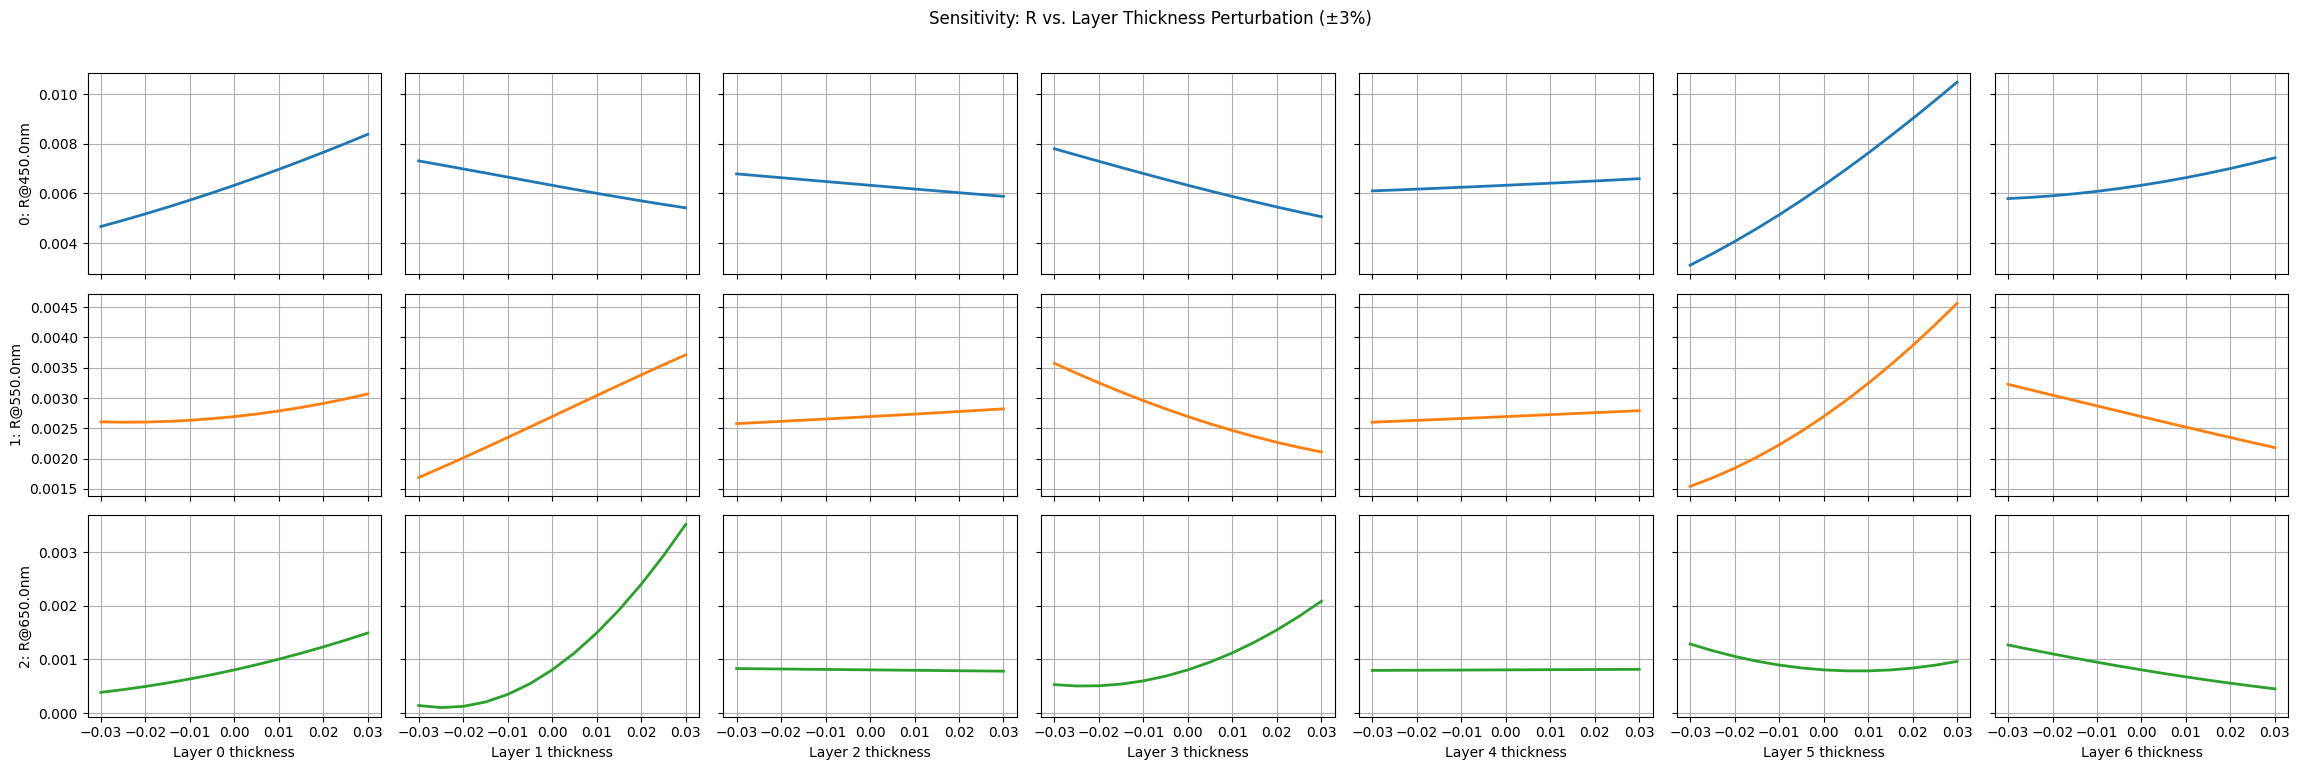

In [4]:
tol = ThinFilmTolerancing(stack)

# Operands: reflectance at three key wavelengths
tol.add_operand("R", 450.0)
tol.add_operand("R", 550.0)
tol.add_operand("R", 650.0)

# ±3% thickness perturbation on each of the 7 layers
for i in range(7):
    tol.add_perturbation(i, "thickness", RangeSampler(-0.03, 0.03, 13))

sa = ThinFilmSensitivityAnalysis(tol)
sa.run()

fig, axes = sa.view()
fig.suptitle("Sensitivity: R vs. Layer Thickness Perturbation (±3%)", y=1.02)
fig.tight_layout();

In [5]:
# Identify which layers have the steepest sensitivity slopes
df_sa = sa.get_results()
operand_cols = [c for c in df_sa.columns if c.startswith("0:") or c.startswith("1:") or c.startswith("2:")]

print("Sensitivity range (max - min reflectance) per layer:")
for ptype in df_sa["perturbation_type"].unique():
    mask = df_sa["perturbation_type"] == ptype
    ranges = df_sa.loc[mask, operand_cols].max() - df_sa.loc[mask, operand_cols].min()
    worst = ranges.max()
    print(f"  {ptype}: max ΔR = {worst*100:.3f}%")

Sensitivity range (max - min reflectance) per layer:
  Layer 0 thickness: max ΔR = 0.371%
  Layer 1 thickness: max ΔR = 0.341%
  Layer 2 thickness: max ΔR = 0.091%
  Layer 3 thickness: max ΔR = 0.274%
  Layer 4 thickness: max ΔR = 0.049%
  Layer 5 thickness: max ΔR = 0.737%
  Layer 6 thickness: max ΔR = 0.164%


## 3. Monte Carlo Analysis

We apply normally-distributed thickness errors (2% std, relative) to all 7 layers simultaneously over 500 trials. This models realistic sputtering variability.

In [6]:
tol_mc = ThinFilmTolerancing(stack)

# Operands: reflectance at 5 wavelengths across the band
for wl in [430.0, 480.0, 550.0, 620.0, 670.0]:
    tol_mc.add_operand("R", wl)

# 2% std thickness perturbation on all 7 layers
for i in range(7):
    tol_mc.add_perturbation(
        i, "thickness",
        DistributionSampler("normal", seed=100 + i, loc=0.0, scale=0.02),
    )

mc = ThinFilmMonteCarlo(tol_mc)
mc.run(num_iterations=500)
print(f"Monte Carlo complete: {len(mc.get_results())} trials")

Monte Carlo complete: 500 trials


### 3a. Reflectance distributions at key wavelengths

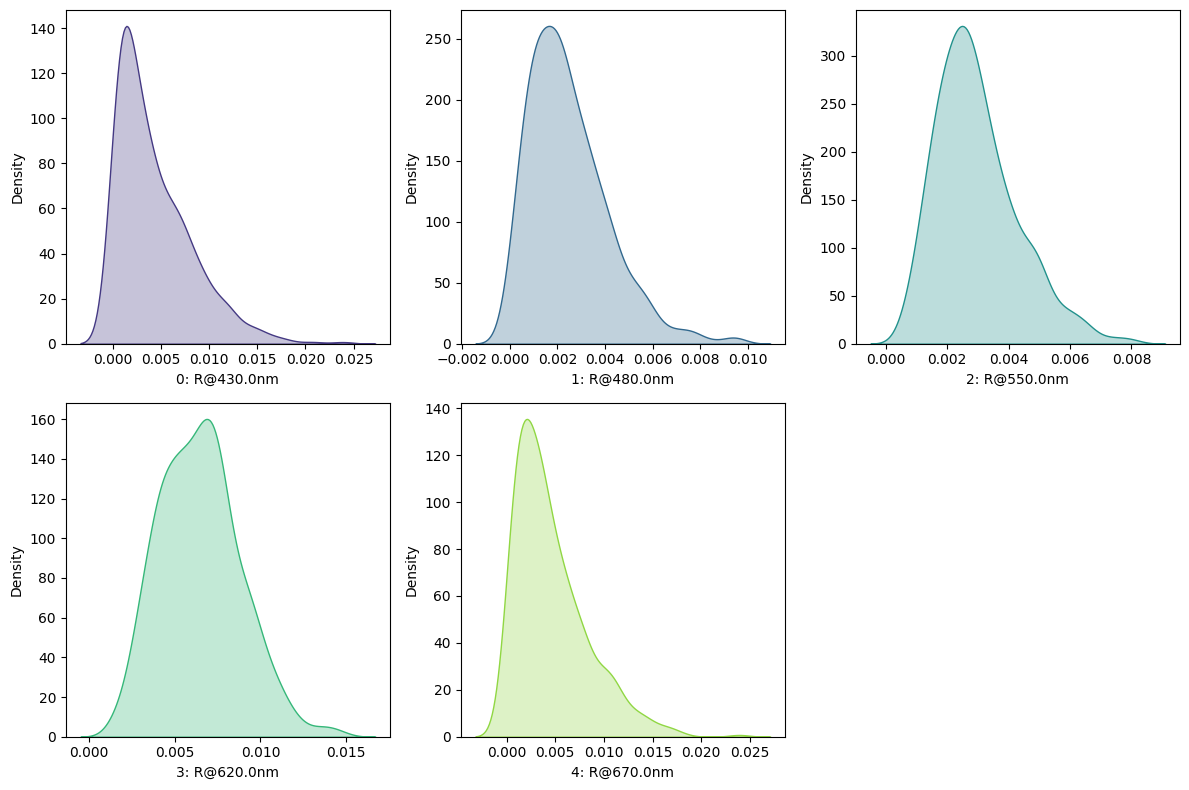

In [7]:
fig, axes = mc.view_histogram(kde=True)

### 3b. Cumulative distribution — yield analysis

Read off yield from the CDF: e.g., what fraction of parts will have R < 1% at each wavelength?

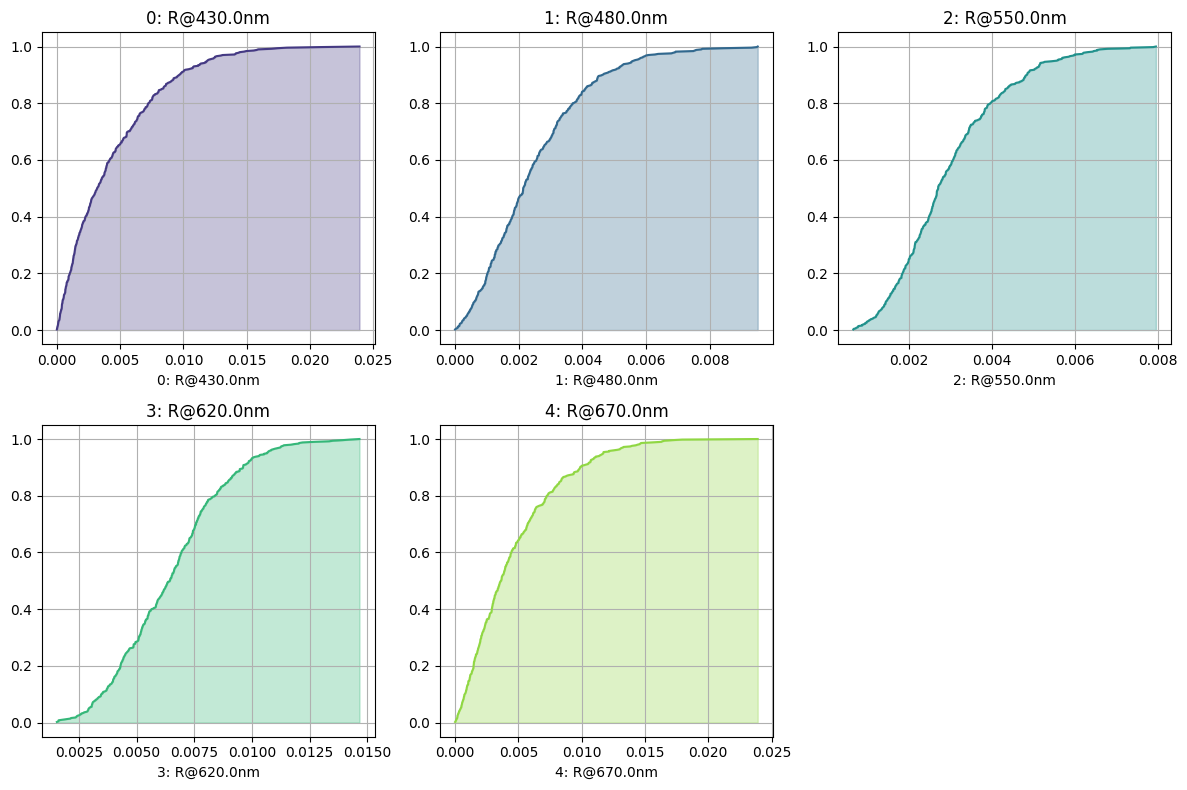

In [8]:
fig, axes = mc.view_cdf()

### 3c. Spectral tolerance band

This is the most informative plot: we compute the **full reflectance spectrum** for 200 random thickness perturbations. The shaded band shows the min/max envelope — the range of spectral performance you should expect in production.

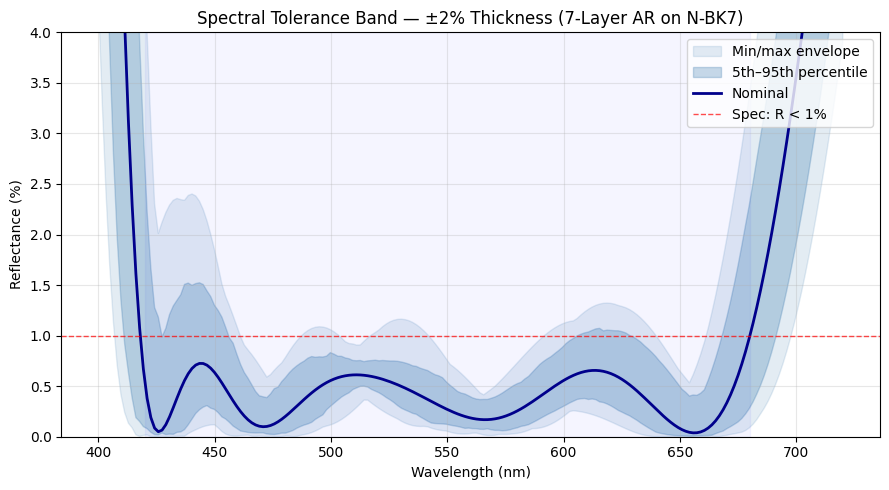

In [9]:
# Store nominal thicknesses
nominal_thicknesses = [layer.thickness_um for layer in stack.layers]
rng = np.random.default_rng(42)

wl_band = np.linspace(400, 720, 200)
n_trials = 200
all_R = np.zeros((n_trials, len(wl_band)))

# Compute nominal spectrum on this grid
R_nom_band = np.array([ThinFilmOperand.reflectance(stack, wl) for wl in wl_band])

for trial in range(n_trials):
    # Apply random ±2% thickness perturbations to all layers
    for i, nom in enumerate(nominal_thicknesses):
        delta = rng.normal(0.0, 0.02)
        stack.layers[i].thickness_um = nom * (1.0 + delta)

    # Compute full spectrum
    all_R[trial] = [ThinFilmOperand.reflectance(stack, wl) for wl in wl_band]

    # Reset to nominal
    for i, nom in enumerate(nominal_thicknesses):
        stack.layers[i].thickness_um = nom

R_min = all_R.min(axis=0)
R_max = all_R.max(axis=0)
R_p05 = np.percentile(all_R, 5, axis=0)
R_p95 = np.percentile(all_R, 95, axis=0)

fig, ax = plt.subplots(figsize=(9, 5))
ax.fill_between(wl_band, R_min * 100, R_max * 100, alpha=0.15, color="steelblue",
                label="Min/max envelope")
ax.fill_between(wl_band, R_p05 * 100, R_p95 * 100, alpha=0.3, color="steelblue",
                label="5th–95th percentile")
ax.plot(wl_band, R_nom_band * 100, "-", color="darkblue", linewidth=2, label="Nominal")
ax.axhline(1.0, color="red", linestyle="--", linewidth=1, alpha=0.7, label="Spec: R < 1%")
ax.axvspan(420, 680, alpha=0.04, color="blue")
ax.set_xlabel("Wavelength (nm)")
ax.set_ylabel("Reflectance (%)")
ax.set_title("Spectral Tolerance Band — ±2% Thickness (7-Layer AR on N-BK7)")
ax.set_ylim(0, 4)
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3)
fig.tight_layout();

### 3d. Summary statistics and yield

In [10]:
df = mc.get_results()
operand_cols = [c for c in df.columns if "R@" in c]

print("Reflectance statistics under ±2% thickness tolerance (500 trials):\n")
print(df[operand_cols].describe().round(6))

# Yield analysis: fraction of parts meeting R < 1% at each wavelength
print("\nYield (fraction with R < 1%):")
for col in operand_cols:
    yield_pct = (df[col] < 0.01).mean() * 100
    print(f"  {col}: {yield_pct:.1f}%")

Reflectance statistics under ±2% thickness tolerance (500 trials):

       0: R@430.0nm  1: R@480.0nm  2: R@550.0nm  3: R@620.0nm  4: R@670.0nm
count    500.000000    500.000000    500.000000    500.000000    500.000000
mean       0.004305      0.002464      0.002961      0.006467      0.004579
std        0.003873      0.001676      0.001325      0.002358      0.003699
min        0.000002      0.000000      0.000652      0.001547      0.000004
25%        0.001296      0.001213      0.002004      0.004630      0.001767
50%        0.003191      0.002141      0.002699      0.006449      0.003648
75%        0.006387      0.003319      0.003732      0.007849      0.006315
max        0.023909      0.009502      0.007952      0.014665      0.023904

Yield (fraction with R < 1%):
  0: R@430.0nm: 91.0%
  1: R@480.0nm: 100.0%
  2: R@550.0nm: 100.0%
  3: R@620.0nm: 93.2%
  4: R@670.0nm: 90.2%


## Interpretation

- The **sensitivity analysis** reveals which layers dominate the error budget — steep curves mean tight thickness control is needed on that layer.
- The **spectral tolerance band** shows the full range of reflectance spectra under manufacturing variations. Where the max envelope crosses the 1% spec line indicates the wavelengths most at risk.
- The **yield analysis** quantifies what fraction of manufactured parts will meet spec at each wavelength — this directly informs go/no-go decisions for production tolerances.
- For this 7-layer AR coating, ±2% thickness control (achievable with modern ion-beam sputtering) keeps reflectance well within spec across most of the band.